In [12]:
import pandas as pd
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria

# 1. Fazendo a consulta no banco de dados de forma assíncrona
async with AsyncSessionLocal() as session:
    resultado = await session.execute(select(ResultadoLoteria))
    loterias = resultado.scalars().all()

# 2. Convertendo os resultados para uma tabela do Pandas (DataFrame)
dados = [item.__dict__ for item in loterias]
df = pd.DataFrame(dados)

# Limpando a coluna interna que o SQLAlchemy usa para controle
if '_sa_instance_state' in df.columns:
    df = df.drop(columns=['_sa_instance_state'])

# 3. Exibindo as 5 primeiras linhas para conferência!
df.head()

,id,horario,data_hora,resultado,tipo_resultado,no_loteria,id_loteria,criado_em,dt_sorteio,dt_horario_sorteio,premio,id_concurso,no_apelido,tempo_restante_segundos
0,46a078af-1dc4-443b-8cd7-fe485ef6bede,21:00,2026-07-15 21:00:00,1125,TD,Nacional,37,2026-07-16 00:22:38.877994,15/07/2026,2026-07-15 21:00:00,1,0,Nacional 21:00,0
1,80a3af92-681a-4ff9-95b0-a78a43267951,21:00,2026-07-15 21:00:00,3923,TD,Nacional,37,2026-07-16 00:22:38.878002,15/07/2026,2026-07-15 21:00:00,2,0,Nacional 21:00,0
2,4fb05751-21c2-42cc-ab7f-c21593263920,21:00,2026-07-15 21:00:00,8296,TD,Nacional,37,2026-07-16 00:22:38.878006,15/07/2026,2026-07-15 21:00:00,3,0,Nacional 21:00,0
3,a5023495-e626-47b9-bfbb-8b97791e6c2a,21:00,2026-07-15 21:00:00,2976,TD,Nacional,37,2026-07-16 00:22:38.878009,15/07/2026,2026-07-15 21:00:00,4,0,Nacional 21:00,0
4,3148959b-a41c-4ca6-8ce1-3d97994c81f9,21:00,2026-07-15 21:00:00,8737,TD,Nacional,37,2026-07-16 00:22:38.878012,15/07/2026,2026-07-15 21:00:00,5,0,Nacional 21:00,0


C:\Users\vinic\AppData\Local\Temp\ipykernel_19152\1477354378.py:27: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\50 - GitHub\lottery-predictive-scraper\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


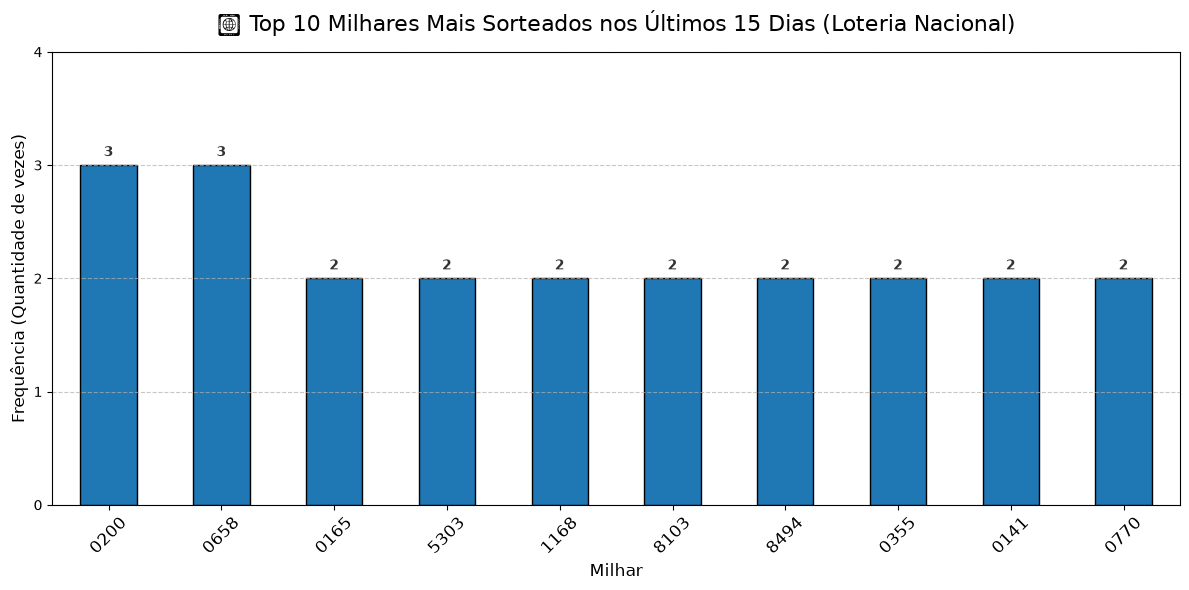

In [13]:
import matplotlib.pyplot as plt

# 1. Garantindo que estamos olhando para a Nacional dentro da nossa janela de 15 dias
df_nacional = df_15_dias[df_15_dias['no_loteria'] == 'Nacional']

# 2. Contando a frequência de cada milhar (resultado completo) e pegando o Top 10
top_10_milhares = df_nacional['resultado'].value_counts().head(10)

# 3. Criando o Gráfico de Barras
plt.figure(figsize=(12, 6))
grafico_milhar = top_10_milhares.plot(kind='bar', color='#1f77b4', edgecolor='black')

# 4. Deixando o gráfico com cara de relatório profissional
plt.title('🎯 Top 10 Milhares Mais Sorteados nos Últimos 15 Dias (Loteria Nacional)', fontsize=16, pad=15)
plt.xlabel('Milhar', fontsize=12)
plt.ylabel('Frequência (Quantidade de vezes)', fontsize=12)
plt.xticks(rotation=45, fontsize=12)

# Ajuste no eixo Y para garantir que mostre números inteiros (já que a frequência será baixa)
plt.yticks(range(0, int(top_10_milhares.max()) + 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando os números exatos em cima de cada barra
for i, v in enumerate(top_10_milhares):
    grafico_milhar.text(i, v + 0.05, str(v), ha='center', va='bottom', fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import itertools
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria

# 1. Carregando os dados do banco atualizado
async with AsyncSessionLocal() as session:
    resultado = await session.execute(select(ResultadoLoteria))
    loterias = resultado.scalars().all()

df = pd.DataFrame([item.__dict__ for item in loterias])
df['data_hora'] = pd.to_datetime(df['data_hora'])

# 2. Tabela de conversão (Bichos)
TABELA_BICHOS = {
    1: "AVESTRUZ", 2: "ÁGUIA", 3: "BURRO", 4: "BORBOLETA", 5: "CACHORRO",
    6: "CABRA", 7: "CARNEIRO", 8: "CAMELO", 9: "COBRA", 10: "COELHO",
    11: "CAVALO", 12: "ELEFANTE", 13: "GALO", 14: "GATO", 15: "JACARÉ",
    16: "LEÃO", 17: "MACACO", 18: "PORCO", 19: "PAVÃO", 20: "PERU",
    21: "TOURO", 22: "TIGRE", 23: "URSO", 24: "VEADO", 25: "VACA"
}

def converter_para_grupo(dezena_str):
    try:
        dezena_int = int(dezena_str)
        if dezena_int == 0: return 25
        return ((dezena_int - 1) // 4) + 1
    except ValueError:
        return None

df['dezena'] = df['resultado'].str[-2:]
df['grupo'] = df['dezena'].apply(converter_para_grupo)
df['bicho'] = df['grupo'].map(TABELA_BICHOS)

# 3. Filtrando o período (Últimos 15 dias para termos dados consistentes)
data_recente = df['data_hora'].max()
data_limite = data_recente - pd.Timedelta(days=15)
df_15_dias = df[df['data_hora'] >= data_limite].copy()

# 4. Separando os DataFrames por Loteria
df_nacional = df_15_dias[df_15_dias['no_loteria'] == 'Nacional']
df_26_sorte = df_15_dias[df_15_dias['no_loteria'] == '26 da Sorte']

def gerar_relatorio_preditivo(nome_loteria, df_loteria):
    grupos_quentes = df_loteria['grupo'].value_counts().head(6).index.tolist()
    combinacoes = list(itertools.combinations(grupos_quentes, 3))[:10]
    
    print(f"==================================================")
    print(f"🔮 PREVISÕES PARA A LOTERIA: {nome_loteria.upper()} 🔮")
    print(f"==================================================")
    print("🔥 TOP 6 GRUPOS MAIS QUENTES:")
    for g in grupos_quentes:
        print(f"   Grupo {g:02d} - {TABELA_BICHOS[g]}")
    print("\n🎲 10 SUGESTÕES DE TERNOS DE GRUPO:")
    for i, terno in enumerate(combinacoes, 1):
        b1, b2, b3 = TABELA_BICHOS[terno[0]], TABELA_BICHOS[terno[1]], TABELA_BICHOS[terno[2]]
        print(f"   Terno {i:02d}: Grupo {terno[0]:02d} ({b1}) | Grupo {terno[1]:02d} ({b2}) | Grupo {terno[2]:02d} ({b3})")
    print("\n")

# 5. Gerando os relatórios separados
gerar_relatorio_preditivo("Nacional", df_nacional)
gerar_relatorio_preditivo("26 da Sorte", df_26_sorte)

🔮 PREVISÕES PARA A LOTERIA: NACIONAL 🔮
🔥 TOP 6 GRUPOS MAIS QUENTES:
   Grupo 15 - JACARÉ
   Grupo 10 - COELHO
   Grupo 12 - ELEFANTE
   Grupo 08 - CAMELO
   Grupo 16 - LEÃO
   Grupo 19 - PAVÃO

🎲 10 SUGESTÕES DE TERNOS DE GRUPO:
   Terno 01: Grupo 15 (JACARÉ) | Grupo 10 (COELHO) | Grupo 12 (ELEFANTE)
   Terno 02: Grupo 15 (JACARÉ) | Grupo 10 (COELHO) | Grupo 08 (CAMELO)
   Terno 03: Grupo 15 (JACARÉ) | Grupo 10 (COELHO) | Grupo 16 (LEÃO)
   Terno 04: Grupo 15 (JACARÉ) | Grupo 10 (COELHO) | Grupo 19 (PAVÃO)
   Terno 05: Grupo 15 (JACARÉ) | Grupo 12 (ELEFANTE) | Grupo 08 (CAMELO)
   Terno 06: Grupo 15 (JACARÉ) | Grupo 12 (ELEFANTE) | Grupo 16 (LEÃO)
   Terno 07: Grupo 15 (JACARÉ) | Grupo 12 (ELEFANTE) | Grupo 19 (PAVÃO)
   Terno 08: Grupo 15 (JACARÉ) | Grupo 08 (CAMELO) | Grupo 16 (LEÃO)
   Terno 09: Grupo 15 (JACARÉ) | Grupo 08 (CAMELO) | Grupo 19 (PAVÃO)
   Terno 10: Grupo 15 (JACARÉ) | Grupo 16 (LEÃO) | Grupo 19 (PAVÃO)


🔮 PREVISÕES PARA A LOTERIA: 26 DA SORTE 🔮
🔥 TOP 6 GRUPOS MAIS Q

In [17]:
import pandas as pd
import itertools
from collections import Counter
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria

# 1. Carregando os dados MAIS RECENTES do banco
async with AsyncSessionLocal() as session:
    resultado = await session.execute(select(ResultadoLoteria))
    loterias = resultado.scalars().all()

df = pd.DataFrame([item.__dict__ for item in loterias])
df['data_hora'] = pd.to_datetime(df['data_hora'])

# 2. Tabela de conversão (Bichos)
TABELA_BICHOS = {
    1: "AVESTRUZ", 2: "ÁGUIA", 3: "BURRO", 4: "BORBOLETA", 5: "CACHORRO",
    6: "CABRA", 7: "CARNEIRO", 8: "CAMELO", 9: "COBRA", 10: "COELHO",
    11: "CAVALO", 12: "ELEFANTE", 13: "GALO", 14: "GATO", 15: "JACARÉ",
    16: "LEÃO", 17: "MACACO", 18: "PORCO", 19: "PAVÃO", 20: "PERU",
    21: "TOURO", 22: "TIGRE", 23: "URSO", 24: "VEADO", 25: "VACA"
}

def converter_para_grupo(dezena_str):
    try:
        dezena_int = int(dezena_str)
        if dezena_int == 0: return 25
        return ((dezena_int - 1) // 4) + 1
    except ValueError:
        return None

df['dezena'] = df['resultado'].str[-2:]
df['grupo'] = df['dezena'].apply(converter_para_grupo)
df['bicho'] = df['grupo'].map(TABELA_BICHOS)

# 3. Filtrando a janela de 15 dias
data_recente = df['data_hora'].max()
data_limite = data_recente - pd.Timedelta(days=15)
df_15_dias = df[df['data_hora'] >= data_limite].copy()

# 4. O Motor Preditivo de Duques (Casais) Isolado por Loteria
def prever_duque_de_grupo(nome_loteria, df_loteria):
    # Agrupamos os bichos de cada sorteio individual
    sorteios = df_loteria.groupby('data_hora')['bicho'].unique()
    
    frequencia_casais = Counter()
    for bichos_no_sorteio in sorteios:
        bichos_validos = [b for b in bichos_no_sorteio if b]
        # Só forma casal se saírem pelo menos 2 bichos diferentes na rodada
        if len(bichos_validos) >= 2:
            bichos_ordenados = sorted(bichos_validos)
            pares = list(itertools.combinations(bichos_ordenados, 2))
            frequencia_casais.update(pares)
            
    # Pegamos os 3 melhores para a nossa estratégia de R$ 3,00
    top_casais = frequencia_casais.most_common(3)
    
    print(f"==================================================")
    print(f"👩‍❤️‍👨 TOP 3 DUQUES PARA A LOTERIA: {nome_loteria.upper()} 👩‍❤️‍👨")
    print(f"==================================================")
    for i, (casal, freq) in enumerate(top_casais, 1):
        print(f"   Top {i:02d}: {casal[0]:<10} & {casal[1]:<10} -> Saíram juntos {freq} vezes")
    print("\n")

# 5. Separando os DataFrames e rodando as previsões
df_nacional = df_15_dias[df_15_dias['no_loteria'] == 'Nacional']
df_26_sorte = df_15_dias[df_15_dias['no_loteria'] == '26 da Sorte']

print("🎯 ESTRATÉGIA PREDITIVA PARA AS 23:00 (ORÇAMENTO: R$ 3,00) 🎯\n")
prever_duque_de_grupo("Nacional", df_nacional)
prever_duque_de_grupo("26 da Sorte", df_26_sorte)

print("DICA PRÁTICA:")
print("Escolha APENAS UMA loteria para jogar às 23:00.")
print("Pegue os 3 casais listados para ela e jogue R$ 1,00 em cada um.")

🎯 ESTRATÉGIA PREDITIVA PARA AS 23:00 (ORÇAMENTO: R$ 3,00) 🎯

👩‍❤️‍👨 TOP 3 DUQUES PARA A LOTERIA: NACIONAL 👩‍❤️‍👨
   Top 01: COELHO     & TIGRE      -> Saíram juntos 13 vezes
   Top 02: COELHO     & PAVÃO      -> Saíram juntos 13 vezes
   Top 03: CAMELO     & COELHO     -> Saíram juntos 13 vezes


👩‍❤️‍👨 TOP 3 DUQUES PARA A LOTERIA: 26 DA SORTE 👩‍❤️‍👨
   Top 01: AVESTRUZ   & BURRO      -> Saíram juntos 50 vezes
   Top 02: AVESTRUZ   & ÁGUIA      -> Saíram juntos 45 vezes
   Top 03: AVESTRUZ   & CABRA      -> Saíram juntos 43 vezes


DICA PRÁTICA:
Escolha APENAS UMA loteria para jogar às 23:00.
Pegue os 3 casais listados para ela e jogue R$ 1,00 em cada um.
